In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# =======================================================
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
# =======================================================
# BƯỚC 1: ĐỌC VÀ MÔ TẢ DỮ LIỆU
# Đọc file CSV
df = pd.read_csv('E:\\smartphones_data.csv.csv')

# Kiểm tra kích thước và liệt kê các cột
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())

# Kiểm tra kiểu dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())

Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   str    
 1   Name                  3260 non-null   str    
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   str    
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null   str    
 

In [46]:
df = df.drop_duplicates()
print(f"\nKích thước sau khi xóa dữ liệu trùng lặp: {df.shape[0]} dòng, {df.shape[1]} cột")


Kích thước sau khi xóa dữ liệu trùng lặp: 3260 dòng, 20 cột


In [47]:
# BƯỚC 2: PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU LỖI
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())


Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [48]:
# Xử lý giá trị thiếu (missing values)
# điền median (trung vị) cho các cột số và mode (yếu tố xuất hiện nhiều nhất) cho cột phân loại

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Xử lý giá trị không hợp lệ & dị thường
# Giá RAM, storage, Battery_cap không được âm hoặc bằng 0
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]

# Số lượng camera không được bằng 0
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]

# Kích thước màn hình <= 8 inch
df = df[df['display_size(inch)'] <= 8]


# Xử lý kiểu dữ liệu các biến Categorical Yes/No -> 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Xử lý cột OS
# Gom thành 3 nhóm rõ ràng: 'android', 'ios', và 'other'
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')

In [49]:
# BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ
# =======================================================
print("\n--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---")

# Lọc ra các cột dạng số (để tránh describe cả các cột chữ)
numeric_cols_for_desc = df.select_dtypes(include=[np.number])

summary_stats = numeric_cols_for_desc.describe()

print(summary_stats)


--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---
               Price          RAM      storage   Battery_cap  \
count    3259.000000  3259.000000  3259.000000   3259.000000   
mean    20138.482357     5.062519   111.918168   4163.014115   
std     24024.499703     3.251756   126.719359   1312.330157   
min      2500.000000     0.250000     0.310000   1100.000000   
25%      7490.000000     3.000000    32.000000   3005.000000   
50%     11999.000000     4.000000    64.000000   4500.000000   
75%     21999.000000     8.000000   128.000000   5000.000000   
max    200999.000000    24.000000  1024.000000  22000.000000   

       has_fast_charging  has_fingerprints      has_nfc       has_5g  \
count        3259.000000       3259.000000  3259.000000  3259.000000   
mean            0.473151          0.956122     0.255907     0.307456   
std             0.499355          0.204856     0.436437     0.461511   
min             0.000000          0.000000     0.000000     0.000000   
25%             0

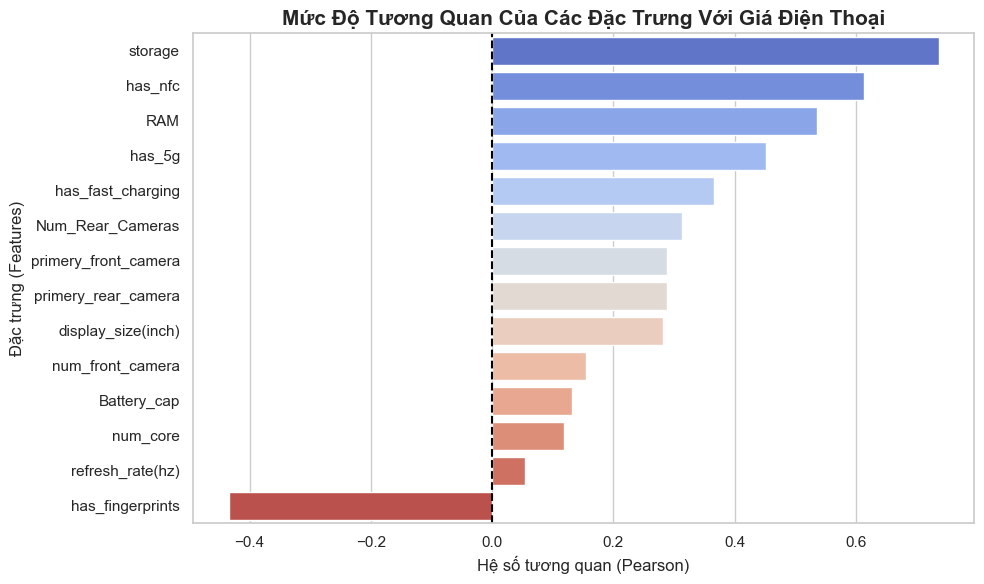

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Lọc các biến dạng số
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Tính tương quan riêng với cột 'Price',
corr_with_price = numeric_df.corr()['Price'].drop('Price').sort_values(ascending=False)

# Vẽ biểu đồ thanh ngang
sns.barplot(x=corr_with_price.values, y=corr_with_price.index, palette='coolwarm')

plt.title('Mức Độ Tương Quan Của Các Đặc Trưng Với Giá Điện Thoại', fontsize=15, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Thêm đường ranh giới 0
plt.tight_layout()
plt.show()

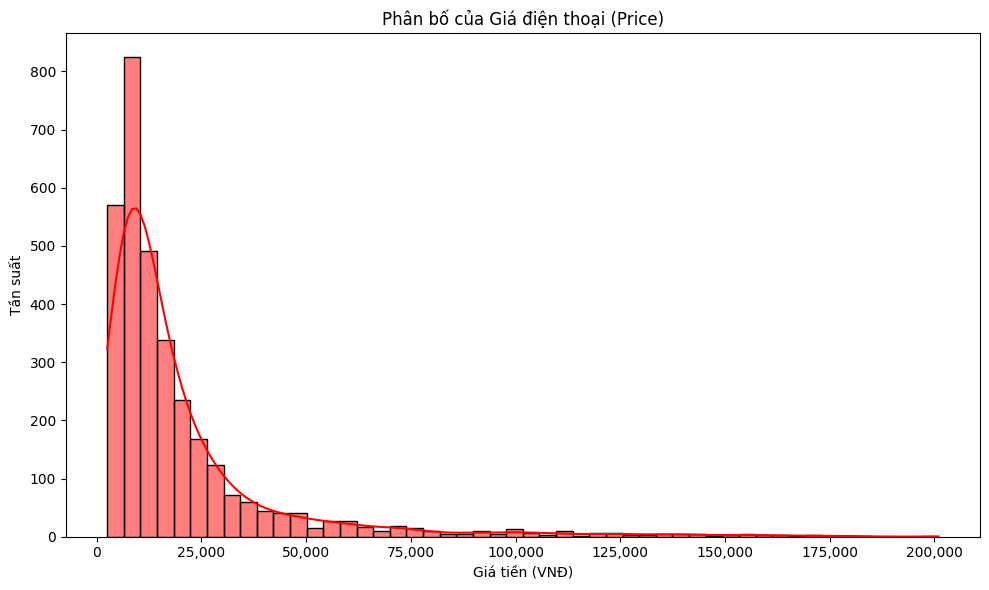

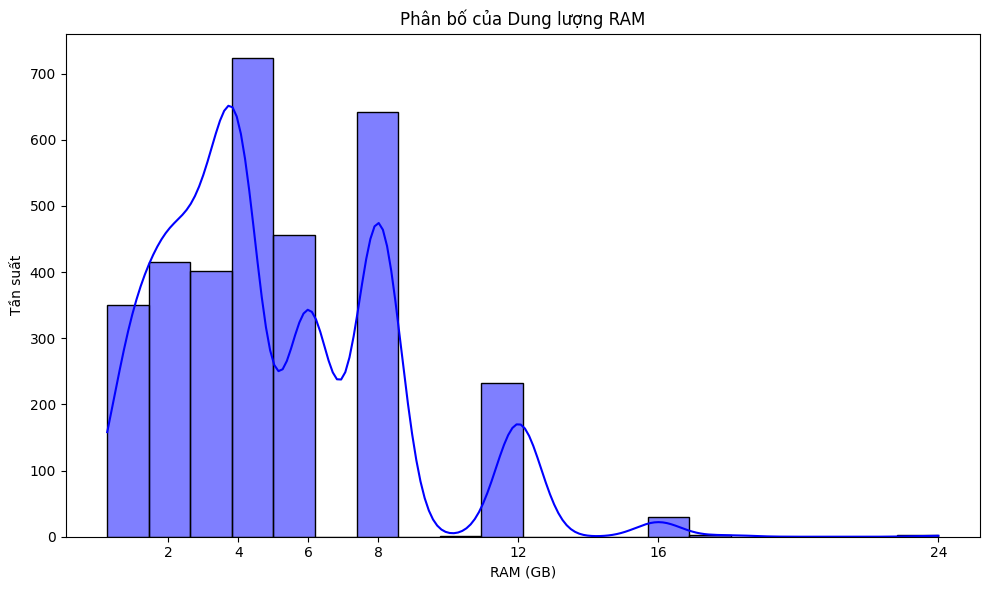

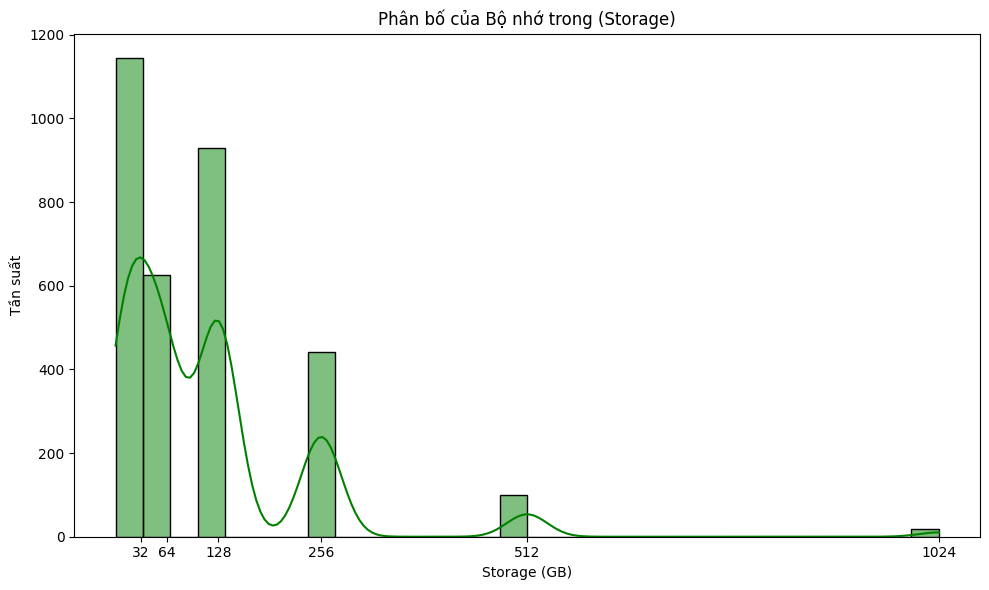

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Thiết lập style đồ thị
sns.set_theme(style="whitegrid")
plt.style.use('default')

# Hàm định dạng dấu phẩy hàng nghìn
comma_formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

# 1. Biểu đồ Giá điện thoại (Price)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price', kde=True, color='red', bins=50, edgecolor='black')
plt.gca().xaxis.set_major_formatter(comma_formatter) # Thêm dấu phẩy hàng nghìn
plt.title('Phân bố của Giá điện thoại (Price)')
plt.xlabel('Giá tiền (VNĐ)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 2. Biểu đồ Dung lượng RAM
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RAM', kde=True, color='blue', bins=20, edgecolor='black')
plt.xticks([2, 4, 6, 8, 12, 16, 24]) # Ép hiển thị đúng các mốc RAM
plt.title('Phân bố của Dung lượng RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 3. Biểu đồ Bộ nhớ trong (Storage)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='storage', kde=True, color='green', bins=30, edgecolor='black')
plt.xticks([32, 64, 128, 256, 512, 1024]) # Ép hiển thị đúng các mốc ROM
plt.title('Phân bố của Bộ nhớ trong (Storage)')
plt.xlabel('Storage (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


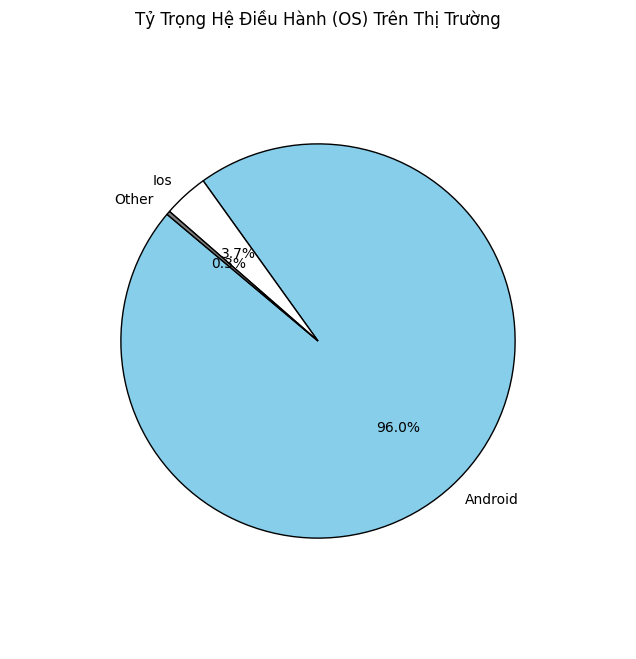

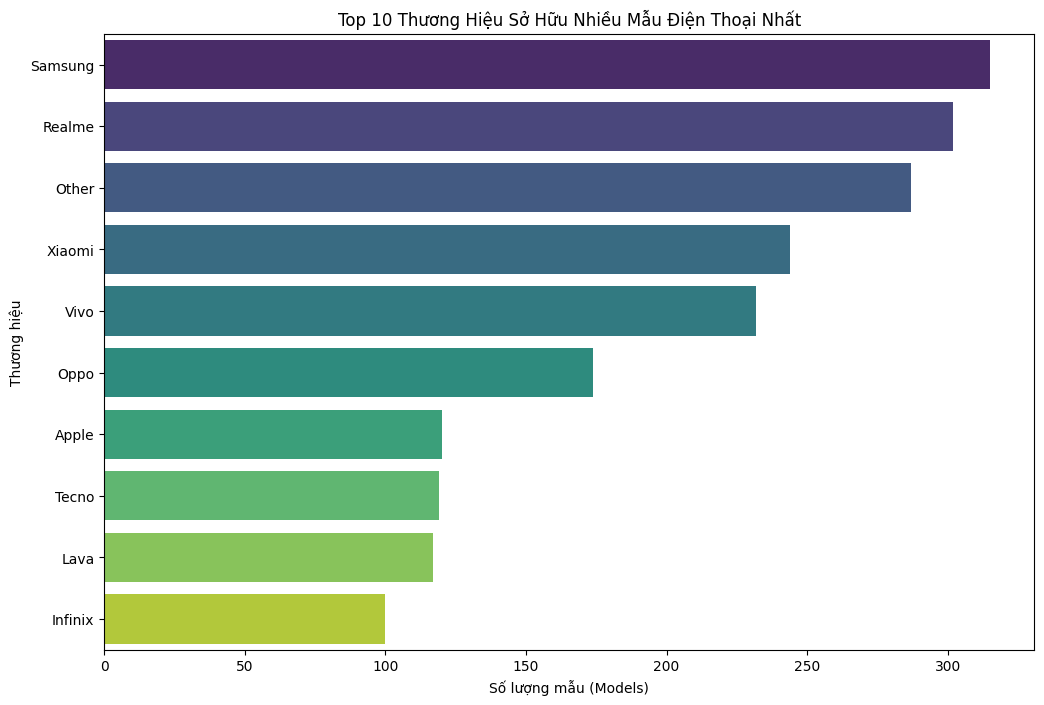

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.style.use('default')

# 1. Hệ điều hành (OS)
plt.figure(figsize=(10, 8))
os_counts = df['OS'].value_counts()
plt.pie(os_counts.values, labels=[label.title() for label in os_counts.index],
        autopct='%1.1f%%', startangle=140, radius=0.8, # Thêm radius=0.8 để thu nhỏ biểu đồ tròn
        colors=['skyblue', 'white', 'gray'],
        wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ Trọng Hệ Điều Hành (OS) Trên Thị Trường')
plt.show()

# 2. Thương hiệu (Brand)
plt.figure(figsize=(12, 8))
top_brands = df['brand_name'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=[str(x).title() for x in top_brands.index], palette="viridis")
plt.title('Top 10 Thương Hiệu Sở Hữu Nhiều Mẫu Điện Thoại Nhất')
plt.xlabel('Số lượng mẫu (Models)')
plt.ylabel('Thương hiệu')
plt.show()

In [36]:
# BƯỚC 3: CHUYỂN ĐỔI DỮ LIỆU VỀ DẠNG PHÙ HỢP

# Bỏ cột 'Name'
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# One-Hot Encoding cho biến categorical: brand_name, processor_brand, display_types
cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Ép kiểu boolean True/False từ get_dummies về dạng 1/0 (số nguyên)
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)

In [37]:
# BƯỚC 4: CHUẨN HÓA GIÁ TRỊ
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột Numeric đầu vào, không chuẩn hóa đầu ra (Price) và các cột Binary (0/1)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

# Thực hiện chuẩn hóa Z-score: z = (x-mean)/s
df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\n Kích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())
print(df.describe())


 Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0        

Kích thước dữ liệu gốc: (3259, 70)


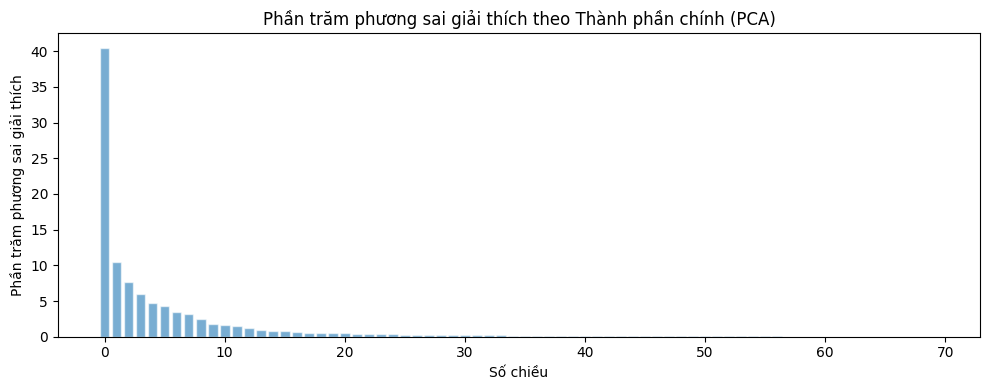

In [38]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# GIẢM CHIỀU BẰNG 2 PHƯƠNG PHÁP (PCA & LDA)
X = df.drop(columns=['Price'])
y = df['Price']

# Tạo y_class (phân loại giá thành 3 nhóm)
y_class = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# Giảm chiều bằng LDA (2 chiều)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_class)

# Giảm chiều bằng PCAA
pca = PCA()
X_pca = pca.fit_transform(X)


plt.style.use('default')
# Lấy mảng tỷ lệ phương sai của từng cột và nhân 100 để ra phần trăm (%)
explained_variance_pct = pca.explained_variance_ratio_ * 100

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(10, 4))

plt.bar(
    range(len(explained_variance_pct)),
    explained_variance_pct,
    alpha=0.6,
    color='tab:blue',
    edgecolor='white'
)

plt.xlabel('Số chiều')
plt.ylabel('Phần trăm phương sai giải thích')
plt.title('Phần trăm phương sai giải thích theo Thành phần chính (PCA)')

plt.tight_layout()
plt.show()

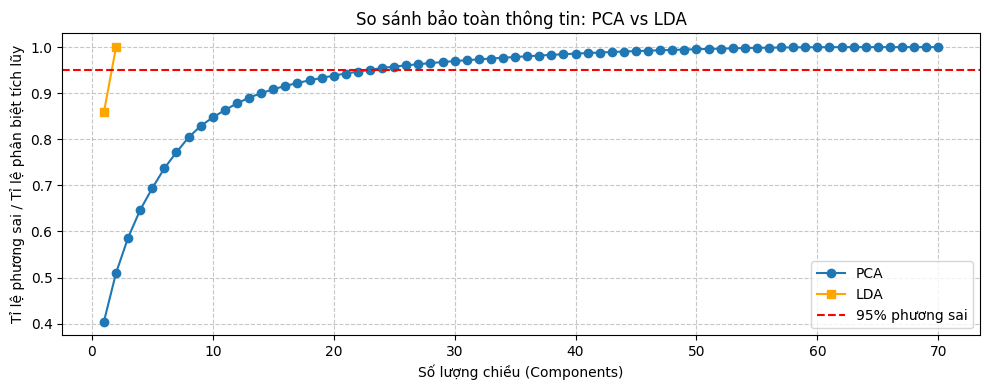

Số chiều chính xác cần để đạt >= 95% phương sai là: 23


In [39]:
plt.figure(figsize=(10, 4))

# Tính toán mảng phương sai tích lũy
pca_variance = np.cumsum(pca.explained_variance_ratio_)
lda_variance = np.cumsum(lda.explained_variance_ratio_)

# Vẽ đồ thị
plt.plot(range(1, len(pca_variance) + 1), pca_variance, marker='o', label='PCA')
plt.plot(range(1, len(lda_variance) + 1), lda_variance, marker='s', label='LDA', color='orange')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% phương sai')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai / Tỉ lệ phân biệt tích lũy')
plt.title('So sánh bảo toàn thông tin: PCA vs LDA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Số chiều chính xác cần để đạt >= 95% phương sai là: {n_components_95}")

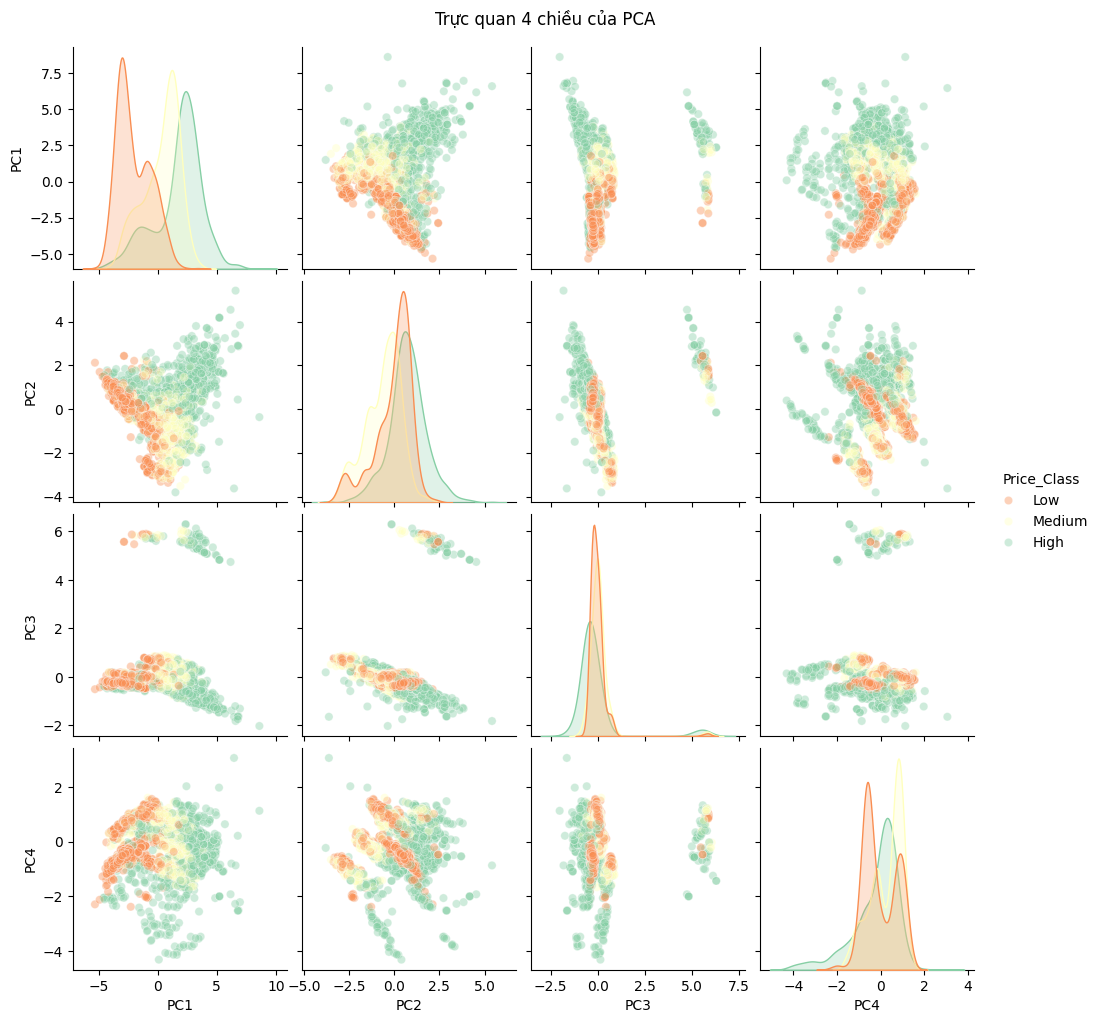

In [40]:
# TRỰC QUAN HÓA THEO 2 CẶP THÀNH PHẦN CHÍNH
# Pairplot cho PCA
df_pca = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Price_Class'] = y_class.values
sns.pairplot(df_pca, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 4 chiều của PCA', y=1.02)
plt.show()

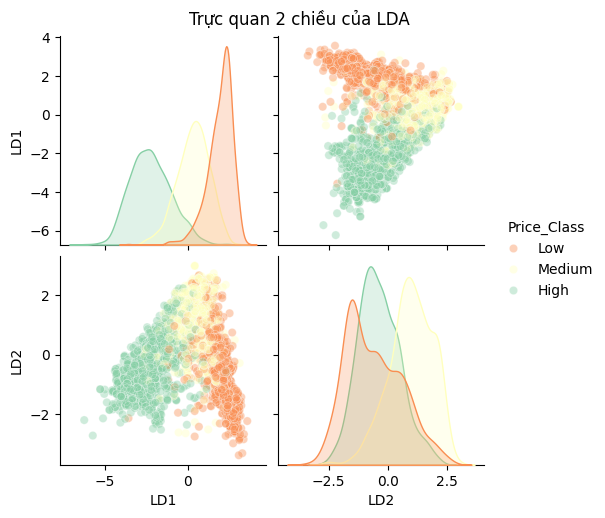

In [240]:
# Pairplot cho LDA
df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['Price_Class'] = y_class.values
sns.pairplot(df_lda, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 2 chiều của LDA', y=1.02)
plt.show()

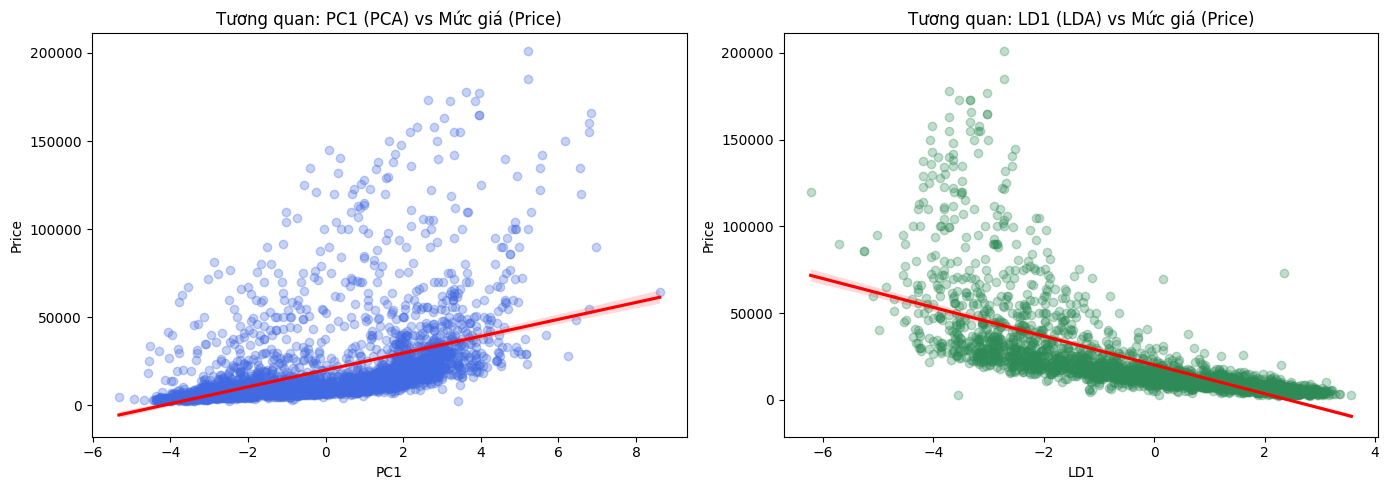

In [241]:
# MỐI QUAN HỆ CHIỀU CHÍNH VỚI ĐẦU RA (TƯƠNG QUAN TUYẾN TÍNH)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 của PCA với Price thực tế
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0], scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Price')

# LD1 của LDA với Price thực tế
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1], scatter_kws={'alpha':0.3, 'color': 'seagreen'}, line_kws={'color':'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 1.3. Phân tích hồi quy




Số chiều sau khi giảm 1/3: 23
Phương sai giải thích: 95.08%

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---
Model              | Tỉ lệ | MAE Gốc (Train/Test)   | R2 Gốc (Train/Test)  | MAE PCA (Train/Test)   | R2 PCA (Train/Test) 
--------------------------------------------------------------------------------------------------------------------------
Linear Regression  | 8:2   | 6785 / 7229            | 0.804 / 0.760        | 6949 / 7512            | 0.782 / 0.731       
                   | 7:3   | 6903 / 7098            | 0.809 / 0.751        | 7079 / 7291            | 0.786 / 0.728       
                   | 6:4   | 7086 / 7142            | 0.807 / 0.766        | 7342 / 7210            | 0.780 / 0.753       
--------------------------------------------------------------------------------------------------------------------------
KNN (k=10)         | 8:2   | 4445 / 5434            | 0.859 / 0.809        | 4540 / 5499            | 0.856 / 0.809       
                   | 7:3   | 4496 / 5392    

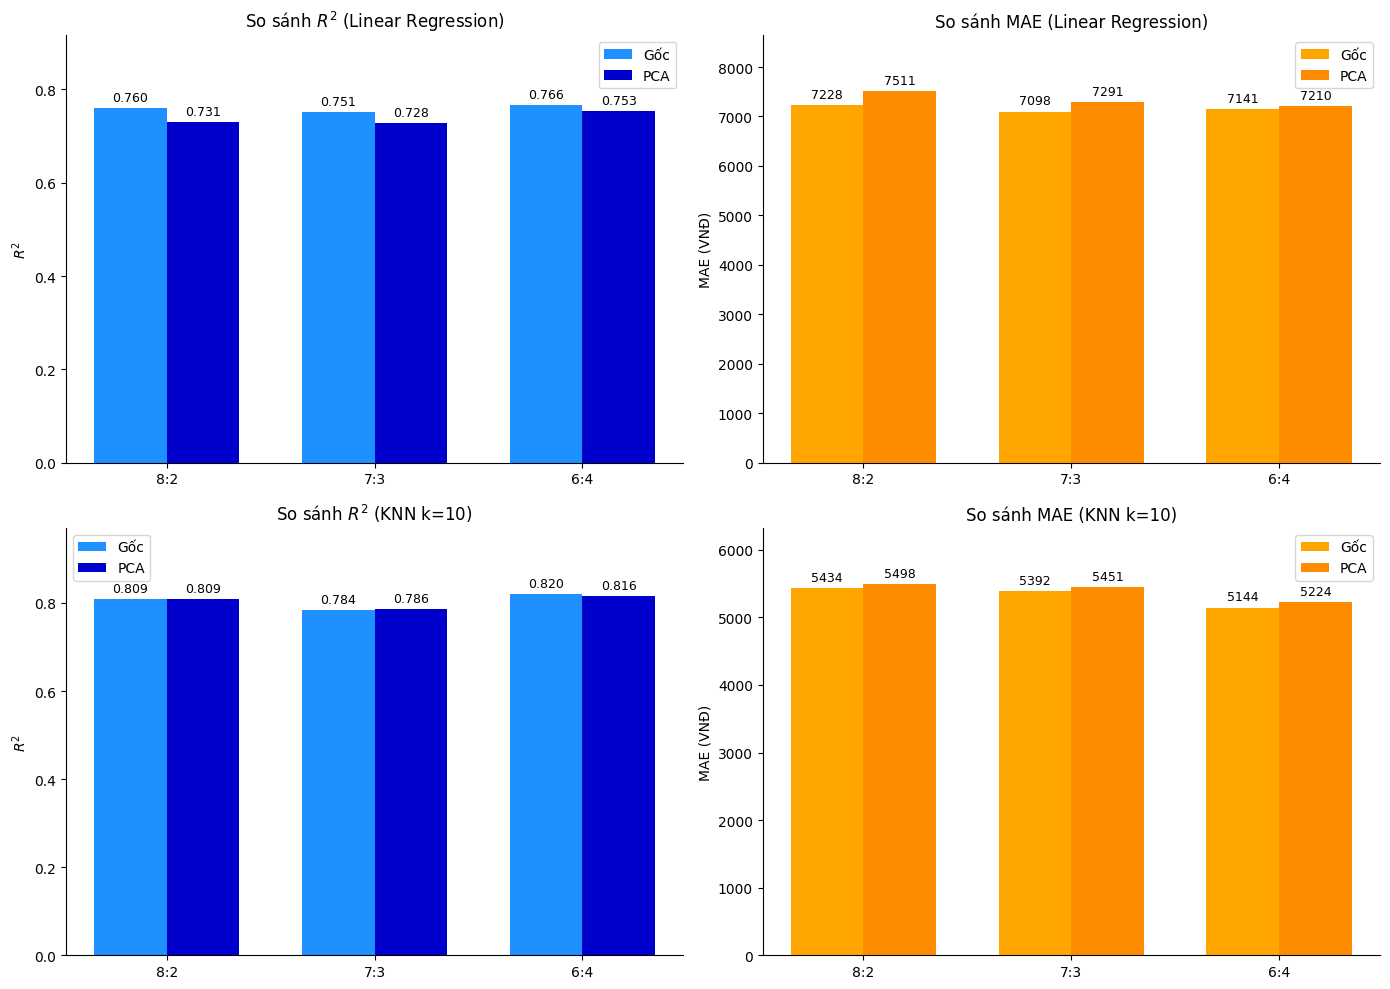

In [242]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# Dữ liệu PCA giảm 1/3 kích thước ban đầu
n_reduced = int(X.shape[1] / 3)
pca = PCA(n_components=n_reduced, random_state=42)
X_reduced = pca.fit_transform(X)
print(f"\nSố chiều sau khi giảm 1/3: {n_reduced}")
print(f"Phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

splits = [0.2, 0.3, 0.4] # test size ứng với 4:1, 7:3, 6:4
models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=10)": KNeighborsRegressor(n_neighbors=10)
}
saved_results = {}

# --- BIẾN LƯU TRỮ DỮ LIỆU VẼ BIỂU ĐỒ ---
lr_r2_goc, lr_r2_pca, lr_mae_goc, lr_mae_pca = [], [], [], []
knn_r2_goc, knn_r2_pca, knn_mae_goc, knn_mae_pca = [], [], [], []

print("--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
header = f"{'Model':<18} | {'Tỉ lệ':<5} | {'MAE Gốc (Train/Test)':<22} | {'R2 Gốc (Train/Test)':<20} | {'MAE PCA (Train/Test)':<22} | {'R2 PCA (Train/Test)':<20}"
print(header)
print("-" * len(header))

# Vòng lặp duyệt Model và Tỉ lệ
for name, model in models.items():
    first_row = True

    for split in splits:
        ratio_str = f"{int((1-split)*10)}:{int(split*10)}"

        # Chia dữ liệu
        X_train_ori, X_test_ori, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
        X_train_red, X_test_red, _, _ = train_test_split(X_reduced, y, test_size=split, random_state=42)

        # Trích xuất trên tập gốc
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test = model.predict(X_test_ori)

        mae_ori_train = mean_absolute_error(y_train, pred_ori_train)
        mae_ori_test = mean_absolute_error(y_test, pred_ori_test)
        r2_ori_train = r2_score(y_train, pred_ori_train)
        r2_ori_test = r2_score(y_test, pred_ori_test)

        # Trích xuất trên tập PCA
        model.fit(X_train_red, y_train)
        pred_red_train = model.predict(X_train_red)
        pred_red_test = model.predict(X_test_red)

        mae_red_train = mean_absolute_error(y_train, pred_red_train)
        mae_red_test = mean_absolute_error(y_test, pred_red_test)
        r2_red_train = r2_score(y_train, pred_red_train)
        r2_red_test = r2_score(y_test, pred_red_test)

        # Lưu kết quả trường hợp 4:1
        if split == 0.2:
            saved_results[name] = {"y_test": y_test, "y_pred": pred_ori_test}

        # --- LƯU DỮ LIỆU ĐỂ VẼ BIỂU ĐỒ (Chỉ lấy điểm Test) ---
        if name == "Linear Regression":
            lr_r2_goc.append(r2_ori_test)
            lr_r2_pca.append(r2_red_test)
            lr_mae_goc.append(mae_ori_test)
            lr_mae_pca.append(mae_red_test)
        elif name == "KNN (k=10)":
            knn_r2_goc.append(r2_ori_test)
            knn_r2_pca.append(r2_red_test)
            knn_mae_goc.append(mae_ori_test)
            knn_mae_pca.append(mae_red_test)

        # In kết quả
        display_name = name if first_row else ""
        mae_ori_str = f"{mae_ori_train:.0f} / {mae_ori_test:.0f}"
        r2_ori_str = f"{r2_ori_train:.3f} / {r2_ori_test:.3f}"
        mae_red_str = f"{mae_red_train:.0f} / {mae_red_test:.0f}"
        r2_red_str = f"{r2_red_train:.3f} / {r2_red_test:.3f}"

        print(f"{display_name:<18} | {ratio_str:<5} | {mae_ori_str:<22} | {r2_ori_str:<20} | {mae_red_str:<22} | {r2_red_str:<20}")
        first_row = False

    print("-" * len(header))

# =====================================================================
# VẼ BIỂU ĐỒ 2x2 (NỀN TRẮNG)
# =====================================================================
labels = ['8:2', '7:3', '6:4']
x = np.arange(len(labels))
width = 0.35

# Sử dụng giao diện mặc định (nền trắng)
plt.style.use('default')

# Tạo lưới 2 hàng x 2 cột, kích thước lớn hơn để không bị đè chữ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
(ax1, ax2), (ax3, ax4) = axes

# Xóa viền trên và viền phải cho tất cả các đồ thị để trông thanh thoát hơn
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# HÀNG 1: LINEAR REGRESSION
# ---------------------------------------------------------
# Cột 1: R2 (Linear Regression)
rects1 = ax1.bar(x - width/2, lr_r2_goc, width, label='Gốc', color='dodgerblue')
rects2 = ax1.bar(x + width/2, lr_r2_pca, width, label='PCA', color='mediumblue')
ax1.set_ylabel('$R^2$')
ax1.set_title('So sánh $R^2$ (Linear Regression)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, max(max(lr_r2_goc), max(lr_r2_pca)) + 0.15)
ax1.legend()
ax1.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
ax1.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

# Cột 2: MAE (Linear Regression)
rects3 = ax2.bar(x - width/2, lr_mae_goc, width, label='Gốc', color='orange')
rects4 = ax2.bar(x + width/2, lr_mae_pca, width, label='PCA', color='darkorange')
ax2.set_ylabel('MAE (VNĐ)')
ax2.set_title('So sánh MAE (Linear Regression)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, max(max(lr_mae_goc), max(lr_mae_pca)) * 1.15)
ax2.legend()
ax2.bar_label(rects3, padding=3, fmt='%d', fontsize=9)
ax2.bar_label(rects4, padding=3, fmt='%d', fontsize=9)

# ---------------------------------------------------------
# HÀNG 2: KNN (k=10)
# ---------------------------------------------------------
# Cột 1: R2 (KNN)
rects5 = ax3.bar(x - width/2, knn_r2_goc, width, label='Gốc', color='dodgerblue')
rects6 = ax3.bar(x + width/2, knn_r2_pca, width, label='PCA', color='mediumblue')
ax3.set_ylabel('$R^2$')
ax3.set_title('So sánh $R^2$ (KNN k=10)')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylim(0, max(max(knn_r2_goc), max(knn_r2_pca)) + 0.15)
ax3.legend()
ax3.bar_label(rects5, padding=3, fmt='%.3f', fontsize=9)
ax3.bar_label(rects6, padding=3, fmt='%.3f', fontsize=9)

# Cột 2: MAE (KNN)
rects7 = ax4.bar(x - width/2, knn_mae_goc, width, label='Gốc', color='orange')
rects8 = ax4.bar(x + width/2, knn_mae_pca, width, label='PCA', color='darkorange')
ax4.set_ylabel('MAE (VNĐ)')
ax4.set_title('So sánh MAE (KNN k=10)')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_ylim(0, max(max(knn_mae_goc), max(knn_mae_pca)) * 1.15)
ax4.legend()
ax4.bar_label(rects7, padding=3, fmt='%d', fontsize=9)
ax4.bar_label(rects8, padding=3, fmt='%d', fontsize=9)

# Tự động căn chỉnh khoảng cách giữa các đồ thị để không bị rối
plt.tight_layout()
plt.show()

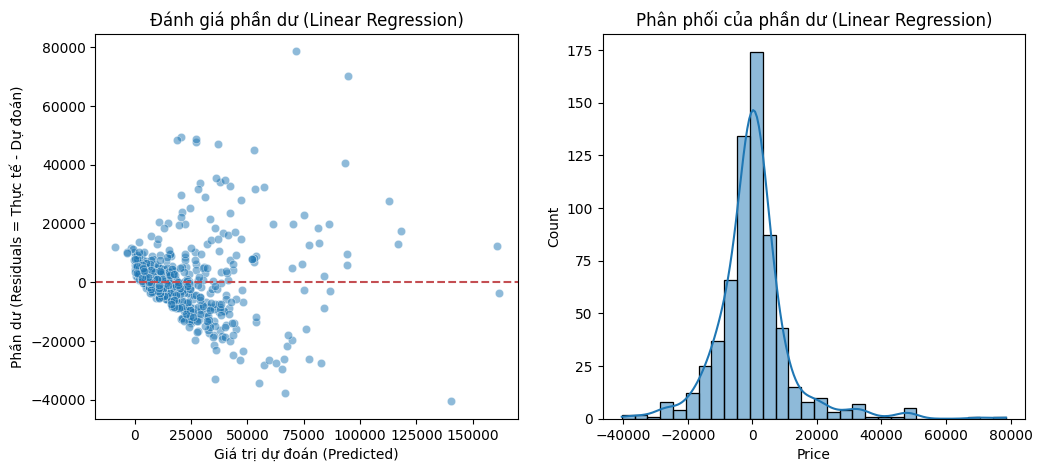

In [243]:
y_test = saved_results["Linear Regression"]["y_test"]
y_pred = saved_results["Linear Regression"]["y_pred"]

# 👉 Tính phần dư
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Giá trị dự đoán (Predicted)')
plt.ylabel('Phần dư (Residuals = Thực tế - Dự đoán)')
plt.title('Đánh giá phần dư (Linear Regression)')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Phân phối của phần dư (Linear Regression)')
plt.show()

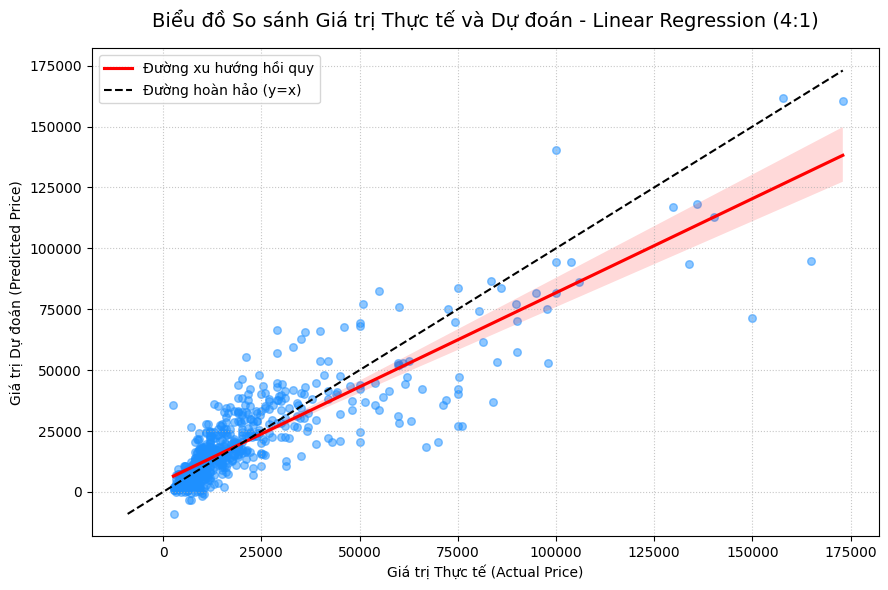

In [244]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# 1. Vẽ các điểm dữ liệu và đường xu hướng hồi quy
# x là Thực tế (Trục hoành), y là Dự đoán (Trục tung)
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha': 0.5, 'color': 'dodgerblue', 's': 30},
    line_kws={'color': 'red', 'label': 'Đường xu hướng hồi quy'}
)

# 2. Vẽ đường hoàn hảo y = x (Nơi Dự đoán chính xác 100% bằng Thực tế)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Đường hoàn hảo (y=x)')

# 3. Thêm nhãn và tiêu đề
plt.xlabel('Giá trị Thực tế (Actual Price)')
plt.ylabel('Giá trị Dự đoán (Predicted Price)')
plt.title('Biểu đồ So sánh Giá trị Thực tế và Dự đoán - Linear Regression (4:1)', fontsize=14, pad=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Hiển thị đồ thị
plt.tight_layout()
plt.show()